In [7]:
import os
import csv
import json
import numpy as np
import torch
import torch.nn as nn
from rdkit import Chem
from rdkit.Chem import AllChem

data_dir = r"C:\Users\pc\Desktop\2026DiffMS\data\canopus"
labels_path = os.path.join(data_dir, "labels.tsv")
spec_dir = os.path.join(data_dir, "subformulae", "subformulae_default")
exec(open(r"C:\Users\pc\Desktop\2026DiffMS\scripts\04_graph_utils.py", encoding="utf-8").read())

print("labels.tsv 存在:", os.path.exists(labels_path))
print("spec_dir 存在:", os.path.exists(spec_dir))

labels.tsv 存在: True
spec_dir 存在: True


In [2]:
#读取前1000条有效的样本
samples = []
with open(labels_path, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter="\t")
    for row in reader:
        spec = row["spec"]
        smiles = row["smiles"]
        json_path = os.path.join(spec_dir, spec + ".json")
        if os.path.exists(json_path) and Chem.MolFromSmiles(smiles) is not None:
            samples.append({"spec": spec, "smiles": smiles, "json_path": json_path})
        if len(samples) >= 1000:
            break

print("样本数:", len(samples))
print("第1条:", samples[0])

样本数: 1000
第1条: {'spec': 'CCMSLIB00000001563', 'smiles': 'CC(C)CC1OC(=O)C2CCCN2C(=O)C(Cc2ccccc2)NC(=O)C(Cc2ccccc2)NC(=O)C(CC(C)C)N(C)C(=O)C2CCCN2C1=O', 'json_path': 'C:\\Users\\pc\\Desktop\\2026DiffMS\\data\\canopus\\subformulae\\subformulae_default\\CCMSLIB00000001563.json'}


In [5]:
#进行谱峰数据的向量化
def binned_spectrum(mz_list, inten_list, max_mz=1000, bin_size=1.0):
    n_bins = int(max_mz / bin_size)
    vec = np.zeros(n_bins, dtype=np.float32)

    for mz, inten in zip(mz_list, inten_list):
        if 0 <= mz < max_mz:
            idx = int(mz / bin_size)
            vec[idx] = max(vec[idx], float(inten))

    if vec.max() > 0:
        vec = vec / vec.max()

    return vec

In [6]:
with open(samples[0]["json_path"], "r", encoding="utf-8") as f:
    obj = json.load(f)

mz = obj["output_tbl"]["mz"]
inten = obj["output_tbl"]["ms2_inten"]
spec_vec = binned_spectrum(mz, inten)

print("峰数量:", len(mz))
print("谱向量形状:", spec_vec.shape)
print("非零 bin 数:", np.count_nonzero(spec_vec))
print("前 10 个非零位置:", np.where(spec_vec > 0)[0][:10])

峰数量: 57
谱向量形状: (1000,)
非零 bin 数: 57
前 10 个非零位置: [100 116 120 121 123 126 151 152 166 172]


In [8]:
X_list = []   # 存每个分子的谱向量
y_list = []   # 存每个分子的指纹
failed = 0

for i, s in enumerate(samples):
    with open(s["json_path"], "r") as f:
        obj = json.load(f)

    mz = obj["output_tbl"]["mz"]
    inten = obj["output_tbl"]["ms2_inten"]
    spec_vec = binned_spectrum(mz, inten)

    mol = Chem.MolFromSmiles(s["smiles"])
    fp = get_fingerprint(mol)

    X_list.append(spec_vec)
    y_list.append(fp)

    if i % 200 == 0:
        print(f"  {i}/{len(samples)}")

print(f"完成: X={len(X_list)} 条, y={len(y_list)} 条")
print(f"X 形状: {X_list[0].shape}")
print(f"y 形状: {y_list[0].shape}")

  0/1000
  200/1000
  400/1000
  600/1000
  800/1000
完成: X=1000 条, y=1000 条
X 形状: (1000,)
y 形状: (2048,)


In [9]:
# X_list 是 Python 列表，每个元素是 numpy 数组 → 堆叠成矩阵
X = np.stack(X_list, axis=0)   # 形状 (1000, 1000)
y = np.stack(y_list, axis=0)   # 形状 (1000, 2048)

# 转成 PyTorch tensor（float32）
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# 取前 800 条训练，后 200 条测试
X_train, X_test = X_tensor[:800], X_tensor[800:]
y_train, y_test = y_tensor[:800], y_tensor[800:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([800, 1000])
y_train: torch.Size([800, 2048])
X_test: torch.Size([200, 1000])
y_test: torch.Size([200, 2048])


In [11]:
#搭建MLP模型
spec_encoder = nn.Sequential(
    nn.Linear(1000, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 2048)
)

In [12]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(spec_encoder.parameters(), lr=1e-4)

print("模型参数量:", sum(p.numel() for p in spec_encoder.parameters()))

模型参数量: 1170176


In [13]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

num_epochs = 50
loss_history = []

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_x, batch_y in train_loader:
        pred = spec_encoder(batch_x)          # (32, 2048)
        loss = loss_fn(pred, batch_y)         # BCEWithLogitsLoss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/{num_epochs}, loss = {avg_loss:.4f}")

Epoch  1/50, loss = 0.6889
Epoch  2/50, loss = 0.6642
Epoch  3/50, loss = 0.5575
Epoch  4/50, loss = 0.3372
Epoch  5/50, loss = 0.1791
Epoch  6/50, loss = 0.1292
Epoch  7/50, loss = 0.1156
Epoch  8/50, loss = 0.1099
Epoch  9/50, loss = 0.1068
Epoch 10/50, loss = 0.1047
Epoch 11/50, loss = 0.1031
Epoch 12/50, loss = 0.1018
Epoch 13/50, loss = 0.1007
Epoch 14/50, loss = 0.0997
Epoch 15/50, loss = 0.0988
Epoch 16/50, loss = 0.0980
Epoch 17/50, loss = 0.0971
Epoch 18/50, loss = 0.0964
Epoch 19/50, loss = 0.0956
Epoch 20/50, loss = 0.0949
Epoch 21/50, loss = 0.0942
Epoch 22/50, loss = 0.0936
Epoch 23/50, loss = 0.0929
Epoch 24/50, loss = 0.0923
Epoch 25/50, loss = 0.0918
Epoch 26/50, loss = 0.0912
Epoch 27/50, loss = 0.0907
Epoch 28/50, loss = 0.0903
Epoch 29/50, loss = 0.0898
Epoch 30/50, loss = 0.0894
Epoch 31/50, loss = 0.0890
Epoch 32/50, loss = 0.0887
Epoch 33/50, loss = 0.0883
Epoch 34/50, loss = 0.0880
Epoch 35/50, loss = 0.0877
Epoch 36/50, loss = 0.0874
Epoch 37/50, loss = 0.0872
E

In [14]:
with torch.no_grad():
    pred_logits = spec_encoder(X_test)         # 原始输出 (200, 2048)
    pred_probs = torch.sigmoid(pred_logits)     # 转成 0~1 概率
    pred_bits = (pred_probs > 0.5).float()      # >0.5 判为 1

    # 计算每个样本的 Tanimoto
    intersection = (pred_bits * y_test).sum(dim=1)    # 两个都是 1
    union = ((pred_bits + y_test) > 0).float().sum(dim=1)  # 至少一个是 1
    tanimoto = (intersection / (union + 1e-8)).mean().item()

print(f"测试集平均 Tanimoto 相似度: {tanimoto:.4f}")

测试集平均 Tanimoto 相似度: 0.1752


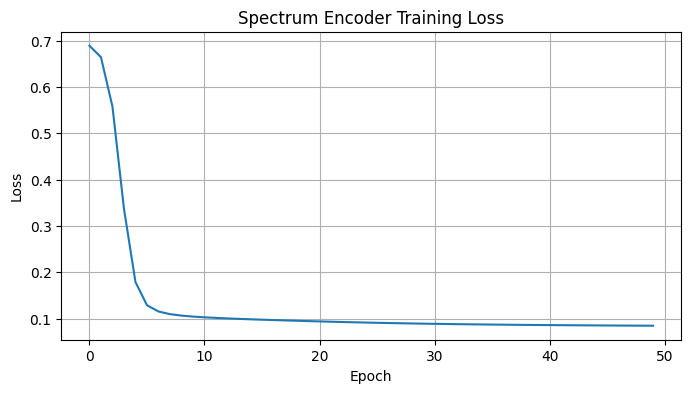

Day 9 完成


In [15]:
# 画 loss 曲线
import matplotlib.pyplot as plt
import os

os.makedirs("../images/DAY9", exist_ok=True)

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Spectrum Encoder Training Loss")
plt.grid(True)
plt.savefig("../images/DAY9/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# 保存日志
with open("../logs/day9_encoder_log.txt", "w") as f:
    f.write(f"Test Tanimoto: {tanimoto:.4f}\n")
    for i, loss in enumerate(loss_history):
        f.write(f"Epoch {i+1}: loss={loss:.4f}\n")

# 保存模型
torch.save(spec_encoder.state_dict(), "../checkpoints/spec_encoder.pth")

print("Day 9 完成")